In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

In [ ]:
from numpy.random import RandomState
X,y_true = make_blobs(n_samples = 500, centers=3, cluster_std=0.60, random_state = 42)

In [ ]:
df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df

,feature_1,feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:
inertia = []
K_range = range(1,11)

In [ ]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state = 42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [ ]:
inertia

[1000.0000000000006,
 297.8954141051723,
 11.575484723104985,
 9.752067977356848,
 8.257175272446279,
 6.917577320416797,
 6.334755391595288,
 5.704177177901426,
 5.060234133532074,
 4.7623618981303935]

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

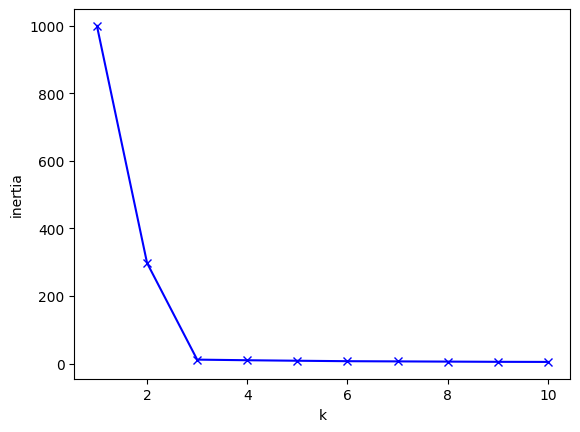

In [ ]:
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('k')
plt.ylabel('inertia')
plt

In [ ]:
kmeans_final = KMeans(n_clusters=3, random_state = 42)
cluster_labels = kmeans_final.fit_predict(X_scaled)


In [ ]:
df['cluster']=cluster_labels

<Axes: xlabel='feature_1', ylabel='feature_2'>

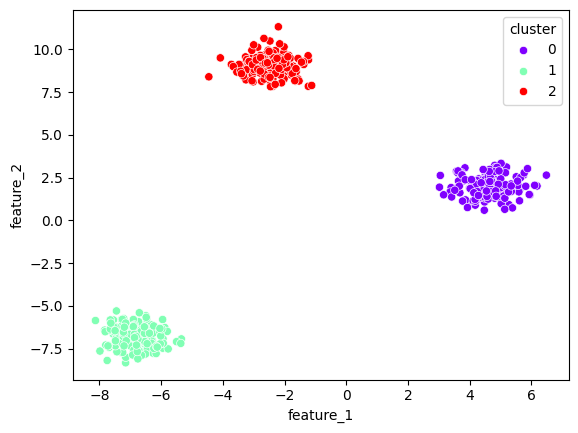

In [ ]:
sns.scatterplot(x=df['feature_1'],
                y=df['feature_2'],
                hue=df['cluster'],
                palette='rainbow'
                )

In [ ]:
from sklearn.datasets import make_moons

In [ ]:
X, y_true = make_moons(n_samples = 500, noise = 0.05, random_state=42)

In [ ]:
df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:
kmeans = KMeans(n_clusters=2, random_state = 42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['cluster']=kmeans_labels

<Axes: xlabel='feature_1', ylabel='feature_2'>

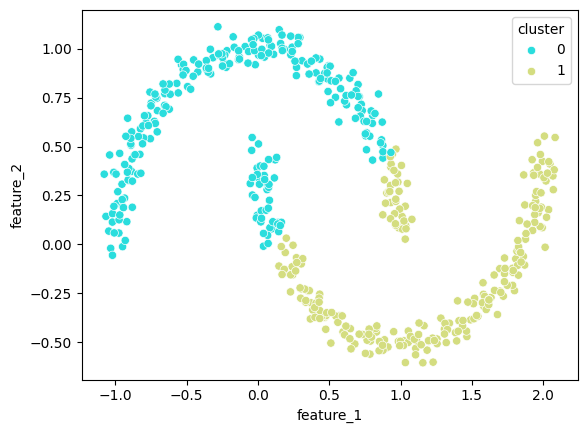

In [ ]:
sns.scatterplot(x=df['feature_1'],
                y=df['feature_2'],
                hue=df['cluster'],
                palette='rainbow'
                )

In [ ]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [ ]:
df['dbscan_cluster']=dbscan_labels # this is done to represent in diagramatical representation

<Axes: xlabel='feature_1', ylabel='feature_2'>

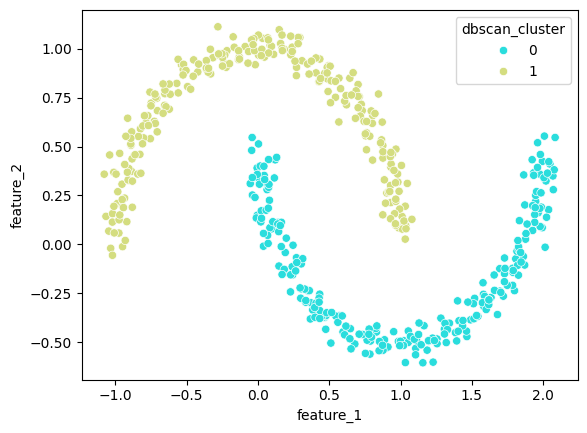

In [ ]:
sns.scatterplot(x=df['feature_1'],
                y=df['feature_2'],
                hue=df['dbscan_cluster'],
                palette='rainbow'
                )

# PCA Dimensions

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA

In [ ]:
X,y = make_blobs(n_samples = 500,n_features=5,centers=3,cluster_std=1.5,random_state = 42)

In [ ]:
X

array([[ -9.85712583,   9.52196609,   6.40680626,  -6.81757623,
         -7.86054541],
       [ -8.04717781,   8.40261648,   6.40946097,  -4.33576029,
         -6.70289196],
       [ -3.73690895,   6.7601386 ,   4.24877609,   0.28504117,
         -7.10318219],
       ...,
       [ -5.82805   ,  -7.29173339,   7.48633693,   2.71623974,
          7.33823548],
       [ -2.48648271,   9.67739715,   6.21190845,   1.03031506,
         -7.54637531],
       [ -8.63901448, -10.68852991,   8.36601977,   4.94211449,
          3.77070371]])

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

array([[-1.07039133,  0.74546814,  0.0859273 , -1.58466105, -0.90798501],
       [-0.52251206,  0.61451192,  0.08731966, -0.95761934, -0.68801347],
       [ 0.78222538,  0.4223533 , -1.04593191,  0.20984645, -0.76407462],
       ...,
       [ 0.14922774, -1.22161917,  0.65212732,  0.82409945,  1.98001159],
       [ 1.16073493,  0.7636525 , -0.01629411,  0.39814317, -0.84828797],
       [-0.70166364, -1.61902103,  1.11350971,  1.38647649,  1.30212699]])

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[ 1.40522818e+00, -1.73079914e+00],
       [ 1.03463536e+00, -9.82792414e-01],
       [ 1.10182830e+00,  1.09084050e+00],
       [-1.76465839e+00,  1.09970698e-01],
       [ 8.59673831e-01, -1.63970361e+00],
       [ 1.09738958e+00,  1.11937509e+00],
       [ 1.04453451e+00,  1.88953610e+00],
       [-3.14810185e+00, -1.06909853e-01],
       [-1.34287183e+00,  7.48033000e-01],
       [ 4.59419122e-01,  9.66806100e-01],
       [ 1.64897776e+00,  1.95384681e+00],
       [ 7.73369393e-01,  2.09584610e+00],
       [-1.92869648e+00,  9.48608771e-02],
       [ 1.15480661e+00, -1.42564791e+00],
       [ 7.07330515e-01, -1.01056640e+00],
       [ 1.59661674e+00, -1.64931961e+00],
       [-2.40550592e+00, -7.53357753e-01],
       [-1.97627695e+00, -3.59747020e-02],
       [ 1.26193015e+00,  2.72813008e+00],
       [ 1.58339885e+00, -1.46125327e+00],
       [ 1.61435981e+00,  1.29812279e+00],
       [-1.74438705e+00,  1.58820049e-01],
       [-1.88938008e+00,  3.66662930e-01],
       [ 6.

In [ ]:
df_pca = pd.DataFrame(X_pca, columns = ['PC1',
                                        'PC2'])
df_pca['label']=y

<Axes: xlabel='PC1', ylabel='PC2'>

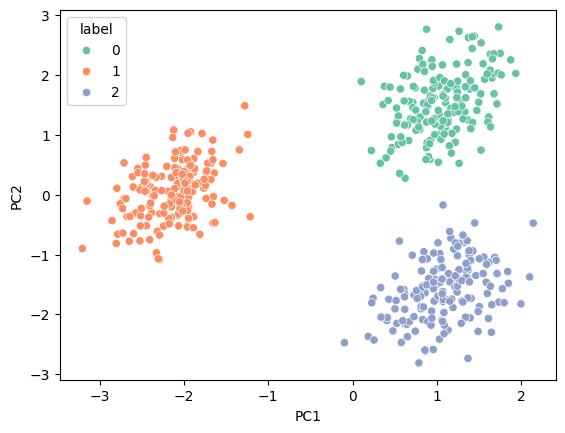

In [ ]:
sns.scatterplot(x=df_pca['PC1'],
                y=df_pca['PC2'],
                hue=df_pca['label'],
                palette='Set2')